# Imports + def's


In [1]:
import os
import numpy as np
from PIL import Image

# Leer datos binarios
def get_binary_data(filename):
    with open(filename, 'rb') as file:
        return list(file.read())

# Crear imagen a partir del bin usando la curva seleccionada
def create_image_from_bin(bin_data, curve_function):
    image_array = np.zeros((32, 32), dtype=np.uint8)
    
    if len(bin_data) < 1024:
        bin_data += [0] * (1024 - len(bin_data))
    
    flat_bin = np.array(bin_data[:1024], dtype=np.uint8)

    for y in range(32):
        for x in range(32):
            index = curve_function(x, y)
            image_array[y, x] = flat_bin[index]

    return Image.fromarray(image_array, mode='L')
# Guardar imagen
def save_image(image, bin_filename, output_folder, curve_name="custom"):
    os.makedirs(output_folder, exist_ok=True)
    parent_folder = os.path.basename(os.path.dirname(bin_filename))
    base_name = os.path.basename(bin_filename)
    output_filename = f"{parent_folder}_{base_name}_{curve_name}.png"
    output_path = os.path.join(output_folder, output_filename)
    image.save(output_path)

# Procesar un archivo bin
def process_single_bin(bin_file, output_folder, curve_function, curve_name="custom"):
    bin_data = get_binary_data(bin_file)
    image = create_image_from_bin(bin_data, curve_function)
    save_image(image, bin_file, output_folder, curve_name=curve_name)

# Procesar todos los archivos de una carpeta
def process_folder(input_folder, output_folder, curve_function, curve_name="custom"):
    bin_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith('.bin')]
    for bin_file in bin_files:
        process_single_bin(bin_file, output_folder, curve_function, curve_name)

# Procesar todas las subcarpetas
def process_all_subfolders(parent_input_dir, parent_output_dir, curve_function, curve_name="custom"):
    subfolders = [os.path.join(parent_input_dir, d) for d in os.listdir(parent_input_dir) if os.path.isdir(os.path.join(parent_input_dir, d))]
    for subfolder in subfolders:
        print(f"🔄 Procesando subcarpeta: {subfolder}")
        process_folder(subfolder, parent_output_dir, curve_function, curve_name)



# Definicion de curvas


In [2]:
def morton_order(x, y):
    """Calcula el índice de Morton (Z-order) intercalando los bits de x e y."""
    z = 0
    for i in range(max(x.bit_length(), y.bit_length())):
        z |= ((x >> i) & 1) << (2 * i + 1)
        z |= ((y >> i) & 1) << (2 * i)
    return z

def h_index(x, y):
    n = 32
    index = 0
    s = n // 2
    
    while s > 0:
        rx = (x & s) >> (s.bit_length() - 1)
        ry = (y & s) >> (s.bit_length() - 1)
        
        index += s * s * ((3 * rx) ^ ry)
        
        x, y = rot(s, x, y, rx, ry)
        
        s //= 2
    
    return index

def hilbert_curve(x, y):
    n = 32
    index = 0
    s = n // 2
    while s > 0:
        rx = 1 if (x & s) else 0
        ry = 1 if (y & s) else 0
        index += s * s * ((3 * rx) ^ ry)
        x, y = rot(s, x, y, rx, ry)
        s //= 2
    return index

def peano_curve(x, y):
    bits = 5
    idx = 0
    for i in range(bits - 1, -1, -1):
        xi = (x >> i) & 1
        yi = (y >> i) & 1
        idx = (idx << 2) | (yi << 1) | xi
    return idx

def beta_omega_curve(x, y):
    bits = 5
    idx = 0
    for i in range(bits - 1, -1, -1):
        xi = (x >> i) & 1
        yi = (y >> i) & 1
        bit_pair = (xi << 1) | yi

        if i % 2 == 1:
            bit_pair ^= 0b11

        idx = (idx << 2) | bit_pair
    return idx


def normal(x, y):
    return y * 32 + x

def rot(s, x, y, rx, ry):
    if ry == 0:
        if rx == 1:
            x = s - 1 - x
            y = s - 1 - y
        x, y = y, x
    return x, y


# Diccionario que asocia nombres a funciones
CURVE_FUNCTIONS = {
    "zorder": morton_order,
    "hilbert": hilbert_curve,
    "peano": peano_curve,
    "normal": normal,
    "hindex": h_index,
    "bocurve": beta_omega_curve
}


# Run


In [3]:
# ==========================
# CONFIGURACIÓN PRINCIPAL
# ==========================

parent_input_directory = r"C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\TESTING\bins"
parent_output_directory = r"C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\TESTING"

curve_name = "zorder"
curve_function = CURVE_FUNCTIONS[curve_name]
parent_output_directory = os.path.join(parent_output_directory, curve_name)

# Ejecutar todo
process_all_subfolders(parent_input_directory, parent_output_directory, curve_function, curve_name)


🔄 Procesando subcarpeta: C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\TESTING\bins\f_AIM_Chat
🔄 Procesando subcarpeta: C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\TESTING\bins\f_Skype_Audio


# Testing


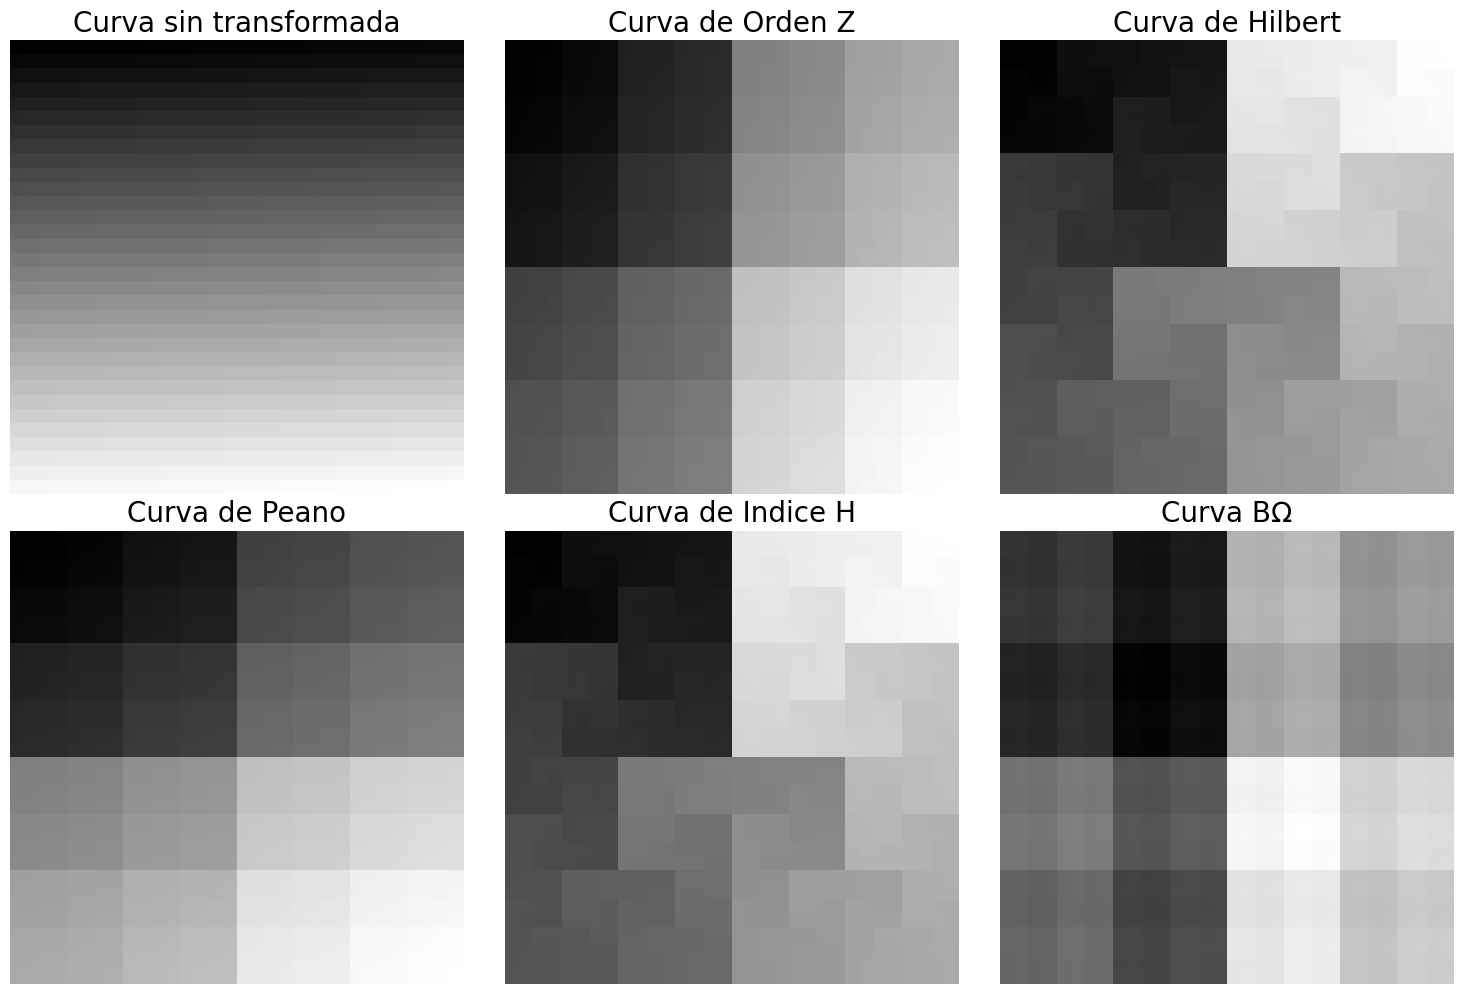

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Crear un binario simulado: valores entre 0 y 255 distribuidos continuamente
simulated_bin_data = np.linspace(0, 255, 1024, dtype=np.uint8)

def create_image_array(bin_data, curve_function):
    image_array = np.zeros((32, 32), dtype=np.uint8)
    flat_bin = np.array(bin_data)

    for y in range(32):
        for x in range(32):
            index = curve_function(x, y)
            image_array[y, x] = flat_bin[index]

    return image_array

# Crear imágenes usando diferentes curvas
image_arrays = {}
curve_names = ["normal", "zorder", "hilbert", "peano", "hindex", "bocurve"]
titles = [
    "Curva sin transformada",
    "Curva de Orden Z",
    "Curva de Hilbert",
    "Curva de Peano",
    "Curva de Indice H",
    "Curva BΩ"
]

for curve_name in curve_names:
    curve_function = CURVE_FUNCTIONS[curve_name]
    image = create_image_array(simulated_bin_data, curve_function)
    image_arrays[curve_name] = image

# Mostrar imágenes en matriz de 2 filas x 3 columnas
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for idx, curve_name in enumerate(curve_names):
    row = idx // 3
    col = idx % 3
    axs[row, col].imshow(image_arrays[curve_name], cmap='gray', interpolation='nearest')
    axs[row, col].set_title(titles[idx], fontsize=20
    )
    axs[row, col].axis('off')


plt.tight_layout()
plt.show()
